# Analyse et prédiction des résultats de matchs

Ce notebook analyse des résultats de matchs internationaux, étudie les tendances sportives et prépare des variables de performance pour entraîner un modèle de machine learning. L'objectif final est de prédire l'équipe la plus susceptible de gagner un match et plus précisement la coupe du monde 2026.

## Préparer l'analyse

Cette cellule importe les bibliothèques utilisées pour charger les données, les analyser et entraîner puis évaluer un modèle de classification.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import (
    ROUND_NAMES,
    add_recent_form,
    get_current_form,
    load_results,
    print_champion,
    print_round,
    team_label,
)

## Charger les résultats

Cette cellule lit le fichier CSV des matchs, affiche quelques informations générales et vérifie que les données contiennent les colonnes attendues.

In [2]:
df = load_results("data/results.csv")

print(f"{len(df)} matchs chargés, de {df['year'].min()} à {df['year'].max()}")
display(df.tail())

49520 matchs chargés, de 1872 à 2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
49515,2026-07-11,Argentina,Switzerland,3,1,FIFA World Cup,Kansas City,United States,True,2026
49516,2026-07-14,France,Spain,0,2,FIFA World Cup,Arlington,United States,True,2026
49517,2026-07-15,England,Argentina,1,2,FIFA World Cup,Atlanta,United States,True,2026
49518,2026-07-18,France,England,4,6,FIFA World Cup,Miami Gardens,United States,True,2026
49519,2026-07-19,Spain,Argentina,1,0,FIFA World Cup,East Rutherford,United States,True,2026


## Filtrer la période étudiée

Cette cellule conserve les matchs compris entre 1994 et juin 2026 afin de travailler sur la période définie pour l'analyse.

In [3]:
df = df[(df['date'] > '1994-01-01') & (df['date'] < '2026-06-27')]

print(f"{len(df)} matchs conservés, de {df['year'].min()} à {df['year'].max()}")

29979 matchs conservés, de 1994 à 2026


## Déterminer l'issue des matchs

Cette cellule crée une variable `outcome` qui indique si l'équipe à domicile gagne, si l'équipe visiteuse gagne ou si le match est nul.

In [4]:
df = df.copy()
df["outcome"] = "draw"
df.loc[df["home_score"] > df["away_score"], "outcome"] = "home_win"
df.loc[df["home_score"] < df["away_score"], "outcome"] = "away_win"

display(df["outcome"].value_counts())

outcome
home_win    14544
away_win     8447
draw         6988
Name: count, dtype: int64

## Mesurer l'avantage à domicile

Cette cellule écarte les matchs joués sur terrain neutre, calcule la proportion de chaque résultat et la représente dans un graphique.

outcome
home_win    0.509091
away_win    0.258555
draw        0.232354
Name: proportion, dtype: float64

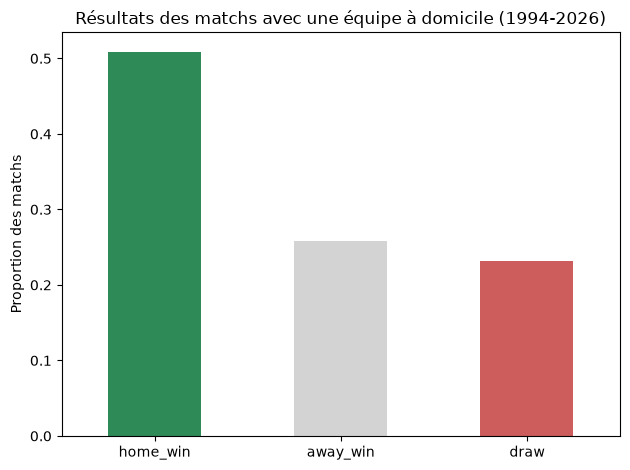

In [5]:
_df = df[df['neutral'] == False]
home_advantage = _df['outcome'].value_counts(normalize=True)

display(home_advantage)

home_advantage.plot(kind="bar", color=["seagreen", "lightgray", "indianred"])
plt.title("Résultats des matchs avec une équipe à domicile (1994-2026)")
plt.ylabel("Proportion des matchs")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Classer les équipes par victoires

Cette cellule identifie le vainqueur de chaque match, compte les victoires par équipe et affiche les dix équipes les plus victorieuses.

winner
Brazil           316
Mexico           309
Spain            274
United States    273
Japan            266
Germany          264
France           263
Saudi Arabia     260
Argentina        257
Iran             248
Name: count, dtype: int64

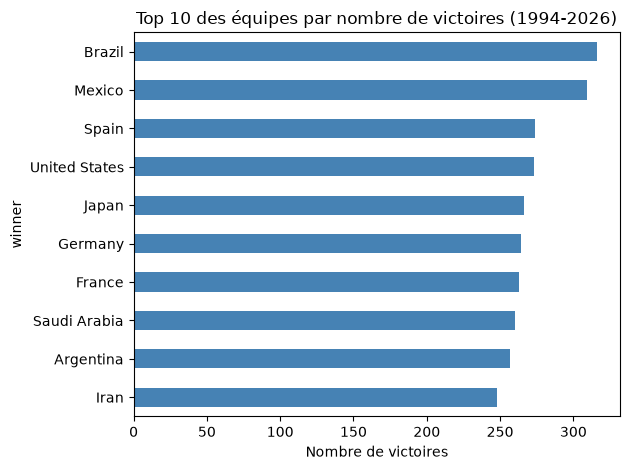

In [6]:
df = df.copy()
df["winner"] = df["home_team"]
df.loc[df["outcome"] == "away_win", "winner"] = df["away_team"]
df.loc[df["outcome"] == "draw", "winner"] = None
top_10_teams = df["winner"].value_counts().sort_values(ascending=False).head(10)

display(top_10_teams)

top_10_teams.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 des équipes par nombre de victoires (1994-2026)")
plt.xlabel("Nombre de victoires")
plt.tight_layout()
plt.show()

## Étudier l'évolution du nombre de buts

Cette cellule calcule le nombre moyen de buts par match pour chaque année et trace son évolution au fil du temps.

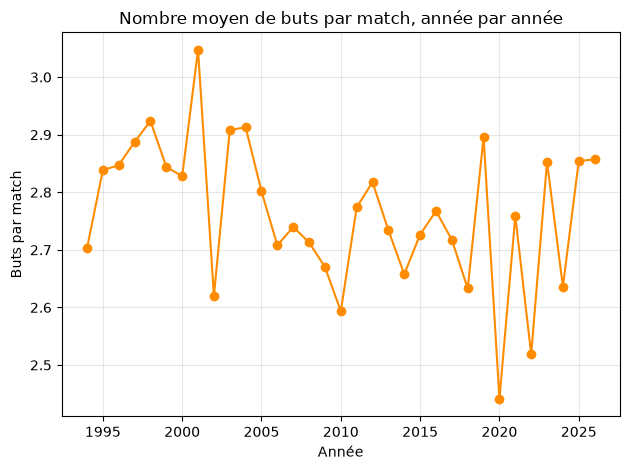

In [7]:
df = df.copy()
df['total_goals'] = df['home_score'] + df['away_score']
goals_per_year = df.groupby('year')['total_goals'].mean()

goals_per_year.plot(kind="line", marker="o", color="darkorange")
plt.title("Nombre moyen de buts par match, année par année")
plt.ylabel("Buts par match")
plt.xlabel("Année")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Calculer la forme récente

Cette cellule enrichit les matchs avec les statistiques récentes des équipes, puis retire les lignes qui ne disposent pas encore de suffisamment de matchs précédents.

In [8]:
df = add_recent_form(df, window=10, min_matches=5)
df = df.dropna(subset=["home_avg_points", "away_avg_points"]).reset_index(drop=True)

print(f"{len(df)} matchs avec la forme récente des deux équipes")
display(df[["date", "home_team", "away_team", "home_avg_points", "away_avg_points"]].tail())

28822 matchs avec la forme récente des deux équipes


,date,home_team,away_team,home_avg_points,away_avg_points
28817,2026-06-26,New Zealand,Belgium,0.5,2.0
28818,2026-06-26,Cape Verde,Saudi Arabia,1.2,0.8
28819,2026-06-26,Uruguay,Spain,1.5,2.2
28820,2026-06-26,Norway,France,2.1,2.5
28821,2026-06-26,Senegal,Iraq,1.6,1.3


## Préparer la variable cible

Cette cellule crée une copie des données sans les matchs nuls et transforme le résultat en variable binaire indiquant une victoire à domicile ou non.

In [9]:
data = df.copy()
data.drop(df.loc[data['outcome'] == 'draw'].index, inplace=True)
data["home_win"] = 1
data.loc[data["outcome"] == "away_win", "home_win"] = 0

print(f"{len(data)} matchs avec un vainqueur")
display(data["home_win"].value_counts(normalize=True))

22055 matchs avec un vainqueur


home_win
1    0.631421
0    0.368579
Name: proportion, dtype: float64

## Encoder les variables catégorielles

Cette cellule convertit les indicateurs `neutral` et `Friendly` en variables numériques utilisables par le modèle.

In [10]:
data['is_neutral'] = data['neutral'].astype(int)
data['is_friendly'] = 0
data.loc[data['tournament'] == "Friendly", 'is_friendly'] = 1

display(data[["tournament", "neutral", "is_neutral", "is_friendly"]].head())

,tournament,neutral,is_neutral,is_friendly
0,African Cup of Nations,False,0,0
1,African Cup of Nations,True,1,0
2,African Cup of Nations,True,1,0
3,African Cup of Nations,True,1,0
5,African Cup of Nations,True,1,0


## Créer les écarts de performance

Cette cellule calcule les différences entre les statistiques récentes de l'équipe à domicile et celles de l'équipe visiteuse pour former les variables du modèle.

In [11]:
data['diff_avg_points'] = data['home_avg_points'] - data['away_avg_points']
data['diff_avg_goals_scored'] = data['home_avg_goals_scored'] - data['away_avg_goals_scored']
data['diff_avg_goals_conceded'] = data['home_avg_goals_conceded'] - data['away_avg_goals_conceded']

display(data[["home_team", "away_team", "diff_avg_points", "diff_avg_goals_scored"]].tail())

,home_team,away_team,diff_avg_points,diff_avg_goals_scored
28815,Curaçao,Ivory Coast,-1.0,-0.2
28817,New Zealand,Belgium,-1.5,-1.7
28819,Uruguay,Spain,-0.7,-1.2
28820,Norway,France,-0.4,-0.1
28821,Senegal,Iraq,0.3,0.6


## Définir les données d'apprentissage

Cette cellule sélectionne les variables explicatives, sépare les données en ensembles d'entraînement et de test, puis affiche la répartition obtenue.

In [12]:
FEATURES = [
    "diff_avg_points",
    "diff_avg_goals_scored",
    "diff_avg_goals_conceded",
    "is_neutral",
    "is_friendly",
]

X = data[FEATURES]
y = data['home_win']

X_train = X.head(int(len(X) * (80/100)))
X_test = X.tail((int(len(X) * (20/100))) + 1)

y_train = y.head(int(len(X) * (80/100)))
y_test = y.tail((int(len(X) * (20/100))) + 1)

print(f"{len(X)=}")

print(f"Entraînement : {len(X_train)} matchs | Test : {len(X_test)} matchs")

len(X)=22055
Entraînement : 17644 matchs | Test : 4412 matchs


## Standardiser les variables

Cette cellule ajuste un standardiseur sur l'ensemble d'entraînement et applique la même transformation aux ensembles d'entraînement et de test.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Moyennes des features d'entraînement après standardisation :", X_train_scaled.mean(axis=0).round(3))
print("Écarts-types :", X_train_scaled.std(axis=0).round(3))

Moyennes des features d'entraînement après standardisation : [ 0. -0.  0.  0.  0.]
Écarts-types : [1. 1. 1. 1. 1.]


## Entraîner le modèle de prédiction

Cette cellule entraîne une forêt aléatoire sur les données standardisées, produit les prédictions du jeu de test et calcule la précision du modèle.

In [14]:
model = RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
baseline = y_test.mean()
print(f"Baseline (toujours prédire une victoire à domicile) : {baseline:.1%}")
print(f"Accuracy du modèle : {accuracy:.1%}")

Baseline (toujours prédire une victoire à domicile) : 62.2%
Accuracy du modèle : 66.7%


## Évaluer les prédictions

Cette cellule affiche la matrice de confusion du modèle afin de comparer les victoires à domicile prédites avec les résultats observés.

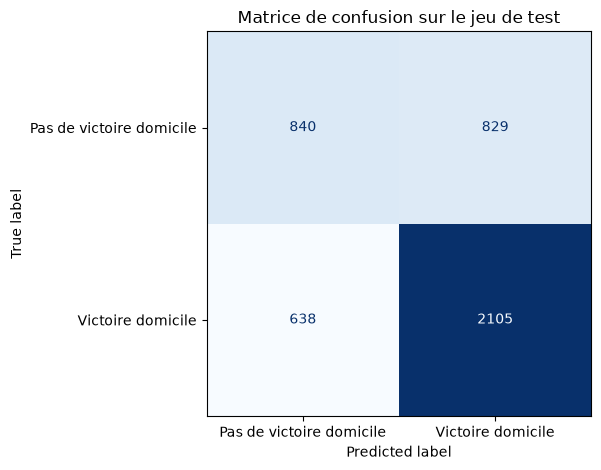

In [15]:
ConfusionMatrixDisplay.from_estimator(
    model, X_test_scaled, y_test,
    display_labels=["Pas de victoire domicile", "Victoire domicile"],
    cmap="Blues", colorbar=False,
)
plt.title("Matrice de confusion sur le jeu de test")
plt.tight_layout()
plt.show()

## Examiner l'importance des variables

Cette cellule extrait l'importance attribuée à chaque feature par la forêt aléatoire et la représente dans un graphique horizontal.

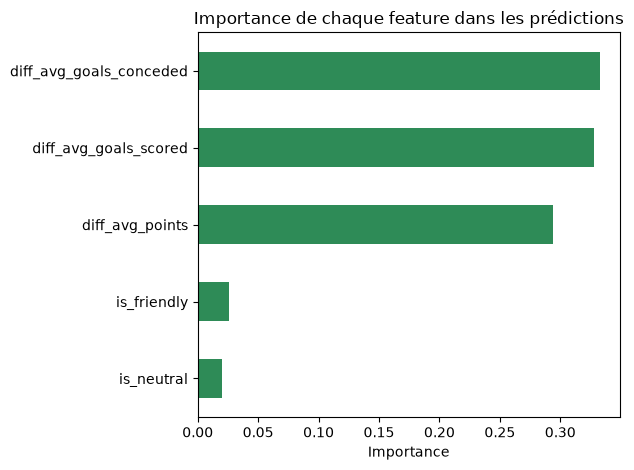

In [16]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind="barh", color="seagreen")
plt.title("Importance de chaque feature dans les prédictions")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Préparer une prédiction de match

Cette cellule définit une fonction qui construit les features de deux équipes, applique le standardiseur et utilise le modèle pour retourner le vainqueur et sa probabilité.

In [ ]:
def predict_match(team_a, team_b):
    """
    Description:
        Predict the winner of a match between two teams on neutral ground.

    Arguments:
        team_a: name of the First team, e.g. 'France'
        team_b: name of the second team, e.g. 'Brazil'

    Returns:
        winner: name of the predicted winner
        probability: probability of the winner winning (between 0.5 and 1)
    """

    form_a = get_current_form(data.sort_values(by="date", ascending=False), team_a)
    form_b = get_current_form(data.sort_values(by="date", ascending=False), team_b)

    features = pd.DataFrame([[form_a['avg_points'] - form_b['avg_points'], 
        form_a['avg_goals_scored'] - form_b['avg_goals_scored'], 
        form_a['avg_goals_conceded'] - form_b['avg_goals_conceded'], 1, 0]], columns=FEATURES)
    
    X_new = features.copy()
    X_new_scaled = scaler.transform(X_new)
    
    proba_a_wins = model.predict_proba(X_new_scaled)[0][1]

    if proba_a_wins >= 0.5:
        return team_a, proba_a_wins
    return team_b, 1 - proba_a_wins


winner, probability = predict_match("France", "Greece")
print(f"France vs Grèce -> victoire de {winner} ({probability:.0%})")

France vs Grèce -> victoire de France (94%)


## Tester des matchs individuels

Cette cellule applique la fonction de prédiction à plusieurs confrontations et affiche le vainqueur estimé ainsi que la probabilité associée.

In [18]:
winner_3, probability_3 = predict_match("France", "Spain")
winner_4, probability_4 = predict_match("Argentina", "Spain")

print(f"France vs Espagne -> victoire de {winner_3} ({probability_3:.0%})")
print(f"Argentine vs Espagne -> victoire de {winner_4} ({probability_4:.0%})")

France vs Espagne -> victoire de France (98%)
Argentine vs Espagne -> victoire de Spain (78%)


## Définir le tableau de la compétition

Cette cellule fixe les affiches du premier tour et prépare les noms des tours suivants pour la simulation.

In [19]:
round_of_32 = [
    ("South Africa", "Canada"),
    ("Germany", "Paraguay"),
    ("Netherlands", "Morocco"),
    ("Brazil", "Japan"),
    ("France", "Sweden"),
    ("Ivory Coast", "Norway"),
    ("Mexico", "Ecuador"),
    ("England", "DR Congo"),
    ("United States", "Bosnia and Herzegovina"),
    ("Belgium", "Senegal"),
    ("Portugal", "Croatia"),
    ("Spain", "Austria"),
    ("Switzerland", "Algeria"),
    ("Argentina", "Cape Verde"),
    ("Colombia", "Ghana"),
    ("Australia", "Egypt"),
]

round_of_16 = [
    ("Canada", "Morocco"), ("Paraguay", "France"),
    ("Brazil", "Norway"), ("Mexico", "England"),
    ("Portugal", "Spain"), ("United States", "Belgium"),
    ("Argentina", "Egypt"), ("Switzerland", "Colombia")
]

round_of_8 = [
    ("France", "Morocco"), ("Spain", "Belgium"),
    ("Norway", "England"), ("Argentina", "Switzerland")
]

round_of_4 = [
    ("Spain", "France"), ("England", "Argentina")
]

round_of_2 = [
    ("Spain", "Argentina")
]

print("Les 32 qualifiés de notre Coupe du Monde 2026 :\n")
for team_a, team_b in round_of_32:
    print(f"  {team_label(team_a):<22} vs {team_label(team_b)}")

Les 32 qualifiés de notre Coupe du Monde 2026 :

  🏳️ South Africa        vs 🇨🇦 Canada
  🇩🇪 Germany             vs 🏳️ Paraguay
  🇳🇱 Netherlands         vs 🇲🇦 Morocco
  🇧🇷 Brazil              vs 🇯🇵 Japan
  🇫🇷 France              vs 🏳️ Sweden
  🏳️ Ivory Coast         vs 🏳️ Norway
  🇲🇽 Mexico              vs 🇪🇨 Ecuador
  🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🏳️ DR Congo
  🇺🇸 United States       vs 🏳️ Bosnia and Herzegovina
  🇧🇪 Belgium             vs 🇸🇳 Senegal
  🇵🇹 Portugal            vs 🇭🇷 Croatia
  🇪🇸 Spain               vs 🇦🇹 Austria
  🇨🇭 Switzerland         vs 🏳️ Algeria
  🇦🇷 Argentina           vs 🏳️ Cape Verde
  🇨🇴 Colombia            vs 🇬🇭 Ghana
  🇦🇺 Australia           vs 🇪🇬 Egypt


## Simuler les tours

Cette cellule fait progresser les équipes dans chaque tour en utilisant le modèle pour prédire les vainqueurs et conserve les résultats de toutes les rencontres.

In [20]:
current_round = round_of_32
all_results = []

for round_name in ROUND_NAMES:
    results = []
    winners = []

    for team_a, team_b in current_round:
        winner, probability = predict_match(team_a, team_b)

        results.append((team_a, team_b, winner, probability))
        winners.append(winner)

    print_round(round_name, results)
    all_results.extend(results)
    current_round = list(zip(winners[::2], winners[1::2]))

print(f"{winners=}")
champion = winners[0]
print_champion(champion)


  SEIZIÈMES DE FINALE
🏳️ South Africa        vs 🇨🇦 Canada              -> 🏳️ South Africa (72%)
🇩🇪 Germany             vs 🏳️ Paraguay            -> 🇩🇪 Germany (74%)
🇳🇱 Netherlands         vs 🇲🇦 Morocco             -> 🇲🇦 Morocco (57%)
🇧🇷 Brazil              vs 🇯🇵 Japan               -> 🇧🇷 Brazil (88%)
🇫🇷 France              vs 🏳️ Sweden              -> 🇫🇷 France (78%)
🏳️ Ivory Coast         vs 🏳️ Norway              -> 🏳️ Norway (77%)
🇲🇽 Mexico              vs 🇪🇨 Ecuador             -> 🇪🇨 Ecuador (82%)
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🏳️ DR Congo            -> 🏴󠁧󠁢󠁥󠁮󠁧󠁿 England (77%)
🇺🇸 United States       vs 🏳️ Bosnia and Herzegovina -> 🇺🇸 United States (74%)
🇧🇪 Belgium             vs 🇸🇳 Senegal             -> 🇸🇳 Senegal (86%)
🇵🇹 Portugal            vs 🇭🇷 Croatia             -> 🇭🇷 Croatia (56%)
🇪🇸 Spain               vs 🇦🇹 Austria             -> 🇪🇸 Spain (71%)
🇨🇭 Switzerland         vs 🏳️ Algeria             -> 🏳️ Algeria (55%)
🇦🇷 Argentina           vs 🏳️ Cape Verde          -> 🇦🇷 Argentina (

## Présenter le parcours du champion

Cette cellule récupère les matchs gagnés par le champion, liste ses adversaires et affiche les probabilités de victoire à chaque tour.

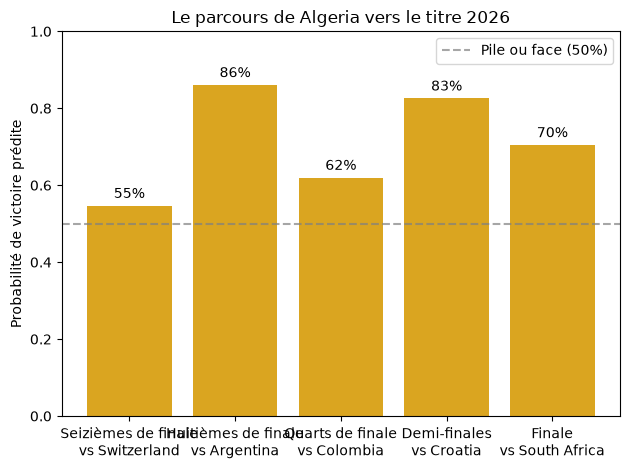

In [21]:
champion_matches = [match for match in all_results if match[2] == champion]
opponents = [f"{name}\nvs {team_a if team_b == champion else team_b}"
             for name, (team_a, team_b, _, _) in zip(ROUND_NAMES, champion_matches)]
probabilities = [match[3] for match in champion_matches]

bars = plt.bar(opponents, probabilities, color="goldenrod")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Pile ou face (50%)")
plt.ylim(0, 1)
plt.ylabel("Probabilité de victoire prédite")
plt.title(f"Le parcours de {champion} vers le titre 2026")
plt.legend()
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width() / 2, prob + 0.02, f"{prob:.0%}", ha="center")
plt.tight_layout()
plt.show()

## Compétences mobilisées et acquis

Ce projet mobilise le nettoyage et l'exploration de données avec pandas, la création de variables explicatives, la séparation des jeux d'entraînement et de test, la standardisation et l'entraînement d'une forêt aléatoire. Il permet d'apprendre à évaluer un modèle de classification, à interpréter ses variables importantes et à utiliser ses prédictions pour comparer des équipes.